# Statistical Analysis of Molecular Dynamics Near a Zn Active Site in Solvent

This project investigates how stochastic solvent configurations influence the electronic and geometric properties of a Zn active site model.

Instead of treating the system as a single optimized structure, we generate an ensemble of configurations by randomly placing a water molecule near the Zn center. Each configuration represents a sample from a distribution of solvent environments.

We then compute observables such as total energy, HOMO–LUMO gap, and Zn–O(water) distance, and analyze their statistical behavior using methods from computational statistics.

**Key Idea:** Molecular systems at finite temperature are inherently stochastic. Therefore, analyzing a distribution of configurations provides more insight than analyzing a single deterministic structure.

In [427]:
from pyscf import gto, dft
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os
import pandas as pd
#from xlwings.pro.reports.filters import width

In [428]:
def angle_between(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.arccos(np.clip(cos_theta, -1.0, 1.0))

## Main User Config of the system and sampling parameters
There are several parameters that can be adjusted to explore different aspects of the system:
- `USE_XYZ_FILE` is True, the code reads the atomic coordinates from the specified XYZ file. The file should have a standard XYZ format with the first two lines as headers and subsequent lines containing element symbols and coordinates.
- `USE_XYZ_FILE` is False, the code uses a simple Zn-only model where the Zn atom is placed at the origin. This allows for testing the sampling and analysis workflow without needing a specific input structure.
- `N_SAMPLES`: Number of random solvent configurations to generate and analyze.
- `BASIS` and `XC`: Computational settings for the PySCF calculations.
- `R_MIN` and `R_MAX`: The range of distances for placing the water molecule around the Zn atom.
- `OUTPUT_DIR`: Directory where results and plots will be saved.

In [429]:
ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

USE_XYZ_FILE = False   # True = use .xyz file, False = use Zn-only

XYZ_FILE = "active_site_202604222145.xyz"

ZN_ONLY_ATOMS = [
    ("Zn", np.array([0.0, 0.0, 0.0]))
]

N_SAMPLES = 2000          # start small first; increase later
BASIS = "lanl2dz"
XC = "HF"

CHARGE = 0              # change if needed
SPIN = 0                # 2S = Nalpha - Nbeta

R_MIN = 0.2             # minimum Zn-O(water) distance in Angstrom
R_MAX = 7.0             # maximum Zn-O(water) distance in Angstrom

OUTPUT_DIR = Path("water_sampling_results")
OUTPUT_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

### Read the base XYZ file or input atomic coordinates directly
- `read_xyz()` function reads the atomic coordinates from the specified XYZ file and returns a list of tuples containing element symbols and their corresponding coordinates.
- `find_zn_position()` function iterates through the list of atoms to find the coordinates of the Zn atom, which will serve as the reference point for placing the water molecule. If no Zn atom is found, it raises a ValueError. This allows the code to work with either a user-provided XYZ file or a simple Zn-only model, depending on the user's choice.


In [430]:
# =========================
# READ BASE XYZ FILE
# =========================

def read_xyz(filename):
    atoms = []

    with open(filename, "r") as f:
        lines = f.readlines()

    for line in lines[2:]:  # skip XYZ header
        parts = line.split()
        if len(parts) == 4:
            elem = parts[0]
            coord = np.array([float(parts[1]), float(parts[2]), float(parts[3])])
            atoms.append((elem, coord))

    return atoms


def find_zn_position(atoms):
    for elem, coord in atoms:
        if elem.lower() == "zn":
            return coord

    raise ValueError("No Zn atom found in the XYZ file.")



# Create the water molecule with realistic geometry
Using the bond length of O-H = 0.96 Å and the angle of H-O-H = 104.5 degrees, we can construct the coordinates of the water molecule. The oxygen atom will be placed at the origin, and the two hydrogen atoms will be positioned according to the specified geometry.


In [431]:
def create_water():
    """
    Creates one water molecule with realistic geometry.
    O-H bond length ~0.96 Angstrom
    H-O-H angle ~104.5 degrees
    """
    OH = 0.96
    angle = np.deg2rad(104.5)

    O = np.array([0.0, 0.0, 0.0])
    H1 = np.array([OH, 0.0, 0.0])
    H2 = np.array([
        OH * np.cos(angle),
        OH * np.sin(angle),
        0.0
    ])

    return np.array([O, H1, H2])

# Random Elements built in to build the dataset
Place water molecule randomly around the Zn atom within the specified distance range. This involves generating random orientations and positions for the water molecule.
- rotation matrix to orient the water molecule randomly in 3D space
- Samples a random point in a spherical shell around Zn.

In [432]:
def random_rotation_matrix():
    """
    Generates a random 3D rotation matrix using a random quaternion.
    """
    u1, u2, u3 = np.random.rand(3)

    q1 = np.sqrt(1 - u1) * np.sin(2 * np.pi * u2)
    q2 = np.sqrt(1 - u1) * np.cos(2 * np.pi * u2)
    q3 = np.sqrt(u1) * np.sin(2 * np.pi * u3)
    q4 = np.sqrt(u1) * np.cos(2 * np.pi * u3)

    R = np.array([
        [1 - 2 * (q3**2 + q4**2), 2 * (q2*q3 - q1*q4),     2 * (q2*q4 + q1*q3)],
        [2 * (q2*q3 + q1*q4),     1 - 2 * (q2**2 + q4**2), 2 * (q3*q4 - q1*q2)],
        [2 * (q2*q4 - q1*q3),     2 * (q3*q4 + q1*q2),     1 - 2 * (q2**2 + q3**2)]
    ])

    return R


def random_position_around(center, r_min=2.0, r_max=5.0):
    """
    Samples a random point in a spherical shell around Zn.
    """
    r = np.random.uniform(r_min, r_max)
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2 * np.pi)

    x = center[0] + r * np.sin(theta) * np.cos(phi)
    y = center[1] + r * np.sin(theta) * np.sin(phi)
    z = center[2] + r * np.cos(theta)

    return np.array([x, y, z])

In [433]:
def water_orientation_parameter(water_coords, zn_position):
    """
    Computes orientation of water relative to Zn.

    cos(theta) = dot product between:
    1. Zn -> O direction
    2. water dipole direction, approximated as O -> midpoint(H1,H2)

    Values:
    +1  = hydrogens point away from Zn
    -1  = hydrogens point toward Zn
     0  = water sideways relative to Zn
    """
    O = water_coords[0]
    H1 = water_coords[1]
    H2 = water_coords[2]

    print(f"O coordinate: {O}")
    print(f"H1 coordinate: {H1}")
    print(f"H2 coordinate: {H2}")

    # Zn-water distance vector
    zn_to_o = O - zn_position
    zn_to_o_unit = zn_to_o / np.linalg.norm(zn_to_o)

    # Approximate water dipole direction: O to midpoint of hydrogens
    h_midpoint = 0.5 * (H1 + H2)
    dipole = h_midpoint - O
    dipole_unit = dipole / np.linalg.norm(dipole)

    print(f"h_midpoint: {h_midpoint}")
    print(f"dipole: {dipole}")
    print(f"dipole_unit: {dipole_unit}")

    cos_theta = np.dot(zn_to_o_unit, dipole_unit)

    theta_deg = np.rad2deg(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

    return cos_theta, theta_deg

## Apply the random rotation and translation to place the water molecule near Zn.
The oxygen atom of the water will be placed at the sampled position

In [434]:
def place_water_near_zn(zn_position, r_min=2.0, r_max=5.0):
    """
    Places one randomly oriented water molecule near Zn.
    The oxygen atom is placed at a sampled distance from Zn.
    """
    water = create_water()

    R = random_rotation_matrix()
    water_rotated = water @ R.T

    oxygen_target = random_position_around(
        zn_position,
        r_min=r_min,
        r_max=r_max
    )

    shift = oxygen_target - water_rotated[0]
    water_final = water_rotated + shift

    return water_final

# Build the geometry string for PySCF and save the XYZ files for each sample.

In [435]:
def build_atom_string(base_atoms, water_coords):
    atom_string = ""

    for elem, coord in base_atoms:
        atom_string += f"{elem} {coord[0]:.8f} {coord[1]:.8f} {coord[2]:.8f}\n"

    atom_string += f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n"
    atom_string += f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n"
    atom_string += f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n"

    return atom_string


def save_xyz(filename, base_atoms, water_coords):
    total_atoms = len(base_atoms) + 3

    with open(filename, "w") as f:
        f.write(f"{total_atoms}\n")
        f.write("Active site with randomly sampled water molecule\n")

        for elem, coord in base_atoms:
            f.write(f"{elem} {coord[0]:.8f} {coord[1]:.8f} {coord[2]:.8f}\n")

        f.write(f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n")
        f.write(f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n")
        f.write(f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n")


# Run the PySCF calculations for each sampled structure and collect the results.

In [436]:
# =========================
# RUN PYSCF
# =========================

def run_pyscf(atom_string):
    mol = gto.M(
        atom=atom_string,
        basis=BASIS,
        unit="Ang",
        charge=CHARGE,
        spin=SPIN
    )

    mf = dft.UKS(mol)
    mf.xc = XC

    energy = mf.kernel()

    mo_energy = mf.mo_energy

    # For UKS, mo_energy has alpha and beta arrays.
    alpha_energies = mo_energy[0]
    alpha_occ = mf.mo_occ[0]

    occupied = alpha_energies[alpha_occ > 0]
    virtual = alpha_energies[alpha_occ == 0]

    homo = occupied[-1]
    lumo = virtual[0]
    gap = lumo - homo

    return energy, homo, lumo, gap, mf.converged


## Main sampling loop
Sample random water configuration and compute the properties to build a statistical distribution. We model the solvent as a stochastic perturbation to the active site. A single water molecule is placed near the Zn center with:

- Random position within a spherical shell
- Random orientation in 3D space

Each configuration is treated as a random sample from an underlying distribution of solvent environments.

This procedure is equivalent to a Monte Carlo sampling method, where each sample represents a possible microstate of the system.

## Statistical Model of the System

Each sampled configuration defines a set of random variables:

- \( R \): Zn–O(water) distance
- \( E \): total electronic energy
- \( $\Delta E$ \): HOMO–LUMO gap

These variables are induced by stochastic solvent placement.

The sampling procedure defines a joint distribution:

\[
P(R, E, $\Delta E$)
\]

which we approximate using Monte Carlo sampling.

Each simulation corresponds to a draw from this distribution.


In [437]:
# =========================
# MAIN SAMPLING LOOP
# =========================

if USE_XYZ_FILE:
    print("Using XYZ file input")
    base_atoms = read_xyz(XYZ_FILE)
else:
    print("Using Zn-only test system")
    base_atoms = ZN_ONLY_ATOMS

zn_position = find_zn_position(base_atoms)

print("Zn position:", zn_position)

# =========================
# CREATE MASTER LOG FILE
# =========================

log_file = OUTPUT_DIR / f"water_sampling_log_{timestamp}.txt"

with open(log_file, "w") as f:
    f.write("Monte Carlo Solvent Sampling Experiment Log\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"Number of samples (N_SAMPLES): {N_SAMPLES}\n\n")

    f.write("Input Structure Metadata\n")
    f.write("-" * 50 + "\n")
    f.write(f"USE_XYZ_FILE: {USE_XYZ_FILE}\n")

    if USE_XYZ_FILE:
        f.write(f"XYZ source file: {XYZ_FILE}\n")
    else:
        f.write("XYZ source file: None\n")
        f.write("Input source: user-provided atom string/list\n")

    f.write(f"Number of base atoms: {len(base_atoms)}\n\n")

    f.write("Base atoms used in simulation:\n")
    for elem, coord in base_atoms:
        f.write(f"{elem} {coord[0]:.8f} {coord[1]:.8f} {coord[2]:.8f}\n")

    f.write("\nPySCF Calculation Settings\n")
    f.write("-" * 50 + "\n")
    f.write(f"Method: UKS\n")
    f.write(f"Functional: {XC}\n")
    f.write(f"Basis: {BASIS}\n")
    f.write(f"Charge: {CHARGE}\n")
    f.write(f"Spin: {SPIN}\n\n")

    f.write("Monte Carlo Water Sampling Settings\n")
    f.write("-" * 50 + "\n")
    f.write(f"Zn-O(water) minimum radius: {R_MIN} Angstrom\n")
    f.write(f"Zn-O(water) maximum radius: {R_MAX} Angstrom\n")
    f.write("Water geometry: O-H = 0.96 Angstrom, H-O-H = 104.5 degrees\n\n")

    f.write("Sample Results\n")
    f.write("=" * 50 + "\n")

results = []

xyz_output_dir = OUTPUT_DIR / f"xyz_samples_{timestamp}"
xyz_output_dir.mkdir(exist_ok=True)

for i in range(N_SAMPLES):
    print(f"\nRunning sample {i + 1}/{N_SAMPLES}")

    water_coords = place_water_near_zn(
        zn_position,
        r_min=R_MIN,
        r_max=R_MAX
    )
    zn_o_distance = np.linalg.norm(water_coords[0] - zn_position)

    O = water_coords[0]
    H1 = water_coords[1]
    H2 = water_coords[2]

    zn_vec = zn_position - O
    oh_vec = H1 - O

    angle_zn_oh = angle_between(zn_vec, oh_vec)

    dipole_vec = (H1 + H2)/2 - O
    dipole_angle = angle_between(dipole_vec, zn_vec)

    normal = np.cross(H1 - O, H2 - O)
    plane_angle = angle_between(normal, zn_vec)

    cos_theta, theta_deg = water_orientation_parameter(
        water_coords,
        zn_position
    )

    atom_string = build_atom_string(base_atoms, water_coords)

    sample_xyz_file = xyz_output_dir / f"sample_{i:04d}.xyz"
    save_xyz(sample_xyz_file, base_atoms, water_coords)

    # ==========================================================
    # Part that actually runs pyscf and collects results
    # ==========================================================
    try:
        energy, homo, lumo, gap, converged = run_pyscf(atom_string)

        results.append({
            "sample": i,
            "zn_o_water_distance_A": zn_o_distance,
            "total_energy_hartree": energy,
            "homo_hartree": homo,
            "lumo_hartree": lumo,
            "gap_hartree": gap,
            "converged": converged,
            "cos_theta_orientation": cos_theta,
            "theta_orientation_deg": theta_deg,
            "xyz_file": str(sample_xyz_file)
        })

        with open(log_file, "a") as f:
            f.write(f"\n--- Sample {i} ---\n")
            f.write(f"XYZ sample file: {sample_xyz_file}\n")
            f.write(f"Zn-O(water) distance (Angstrom): {zn_o_distance:.8f}\n")
            f.write(f"Converged: {converged}\n")
            f.write(f"Final electronic energy (Hartree): {energy:.12f}\n")
            f.write(f"HOMO energy (Hartree): {homo:.12f}\n")
            f.write(f"LUMO energy (Hartree): {lumo:.12f}\n")
            f.write(f"HOMO-LUMO gap (Hartree): {gap:.12f}\n")

            f.write("\nSampled water coordinates:\n")
            f.write(f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n")
            f.write(f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n")
            f.write(f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n")

        print(f"Energy: {energy:.8f} Ha")
        print(f"Zn-O distance: {zn_o_distance:.3f} A")
        print(f"Gap: {gap:.6f} Ha")
        print(f"Converged: {converged}")

    except Exception as e:
        print(f"Sample {i} failed: {e}")

        with open(log_file, "a") as f:
            f.write(f"\n--- Sample {i} FAILED ---\n")
            f.write(f"XYZ sample file: {sample_xyz_file}\n")
            f.write(f"Zn-O(water) distance (Angstrom): {zn_o_distance:.8f}\n")
            f.write(f"Error: {e}\n")

            f.write("\nSampled water coordinates:\n")
            f.write(f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n")
            f.write(f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n")
            f.write(f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n")

        results.append({
            "sample": i,
            "zn_o_water_distance_A": zn_o_distance,
            "total_energy_hartree": np.nan,
            "homo_hartree": np.nan,
            "lumo_hartree": np.nan,
            "cos_theta_orientation": cos_theta,
            "theta_orientation_deg": theta_deg,
            "angle_zn_oh_deg": angle_zn_oh,
            "dipole_angle_deg": dipole_angle,
            "plane_angle_deg": plane_angle,
            "gap_hartree": np.nan,
            "converged": False,
            "xyz_file": str(sample_xyz_file)
        })

# =========================
# SAVE RESULTS
# =========================

df = pd.DataFrame(results)

csv_file = OUTPUT_DIR / f"water_sampling_results_{timestamp}.csv"
df.to_csv(csv_file, index=False)
with open(log_file, "a") as f:
    f.write("\n" + "=" * 50 + "\n")
    f.write("Run Complete\n")
    f.write(f"Results CSV: {csv_file}\n")
    f.write(f"XYZ sample directory: {xyz_output_dir}\n")
    f.write(f"Total attempted samples: {N_SAMPLES}\n")
    f.write(f"Successful numeric rows saved: {df['total_energy_hartree'].notna().sum()}\n")
print("\nDone!")
print(f"Results saved to: {csv_file}")
print(f"XYZ samples saved to: {xyz_output_dir}")

Using Zn-only test system
Zn position: [0. 0. 0.]

Running sample 1/2000
O coordinate: [ 0.04445255 -0.00938364 -3.65572698]
H1 coordinate: [-0.85804706  0.21525722 -3.89369953]
H2 coordinate: [ 0.57901754  0.67163297 -4.0705241 ]
h_midpoint: [-0.13951476  0.4434451  -3.98211182]
dipole: [-0.18396731  0.45282873 -0.32638484]
dipole_unit: [-0.31301406  0.77047253 -0.55533258]
converged SCF energy = -530.383210402787  <S^2> = 2.6574298e-11  2S+1 = 1
Energy: -530.38321040 Ha
Zn-O distance: 3.656 A
Gap: 0.560877 Ha
Converged: True

Running sample 2/2000
O coordinate: [-0.03828153  0.03004063 -0.59624944]
H1 coordinate: [ 0.04810743  0.82145496 -1.13271967]
H2 coordinate: [ 0.86208333 -0.19076711 -0.34687607]
h_midpoint: [ 0.45509538  0.31534393 -0.73979787]
dipole: [ 0.49337691  0.2853033  -0.14354843]
dipole_unit: [ 0.83946385  0.48543376 -0.24424272]
converged SCF energy = -559.941168984482  <S^2> = 1.6477486e-11  2S+1 = 1
Energy: -529.90537547 Ha
Zn-O distance: 4.952 A
Gap: 0.537877 Ha


# Main Statistical Analysis
- Zn-O water distance distribution
- total energy distribution
- HOMO-LUMO gap distribution
- Distance vs energy
- Distance vs HOMO-LUMO Gap
- Energy vs gap
- bootstrapping confidence intervals
- bootstrap histogram: energy mean
- bootstrap histogram: HOMO-LUMO Gap Mean

## Dataset Construction

Each sampled configuration produces a set of observables:

- Zn–O(water) distance
- Total electronic energy
- HOMO energy
- LUMO energy
- HOMO–LUMO gap

These values form a dataset of independent samples, which can be analyzed statistically. Each observable is treated as a random variable influenced by stochastic solvent interactions.

This section constructs the dataset by loading generated results from pyscf calculation above in the csv file and creates necessary output directories

### Change CSV for every new pyscf analysis run to do separate analysis

In [438]:
csv_file = "water_sampling_results/water_sampling_results_2026-05-02_02-28-42.csv"


In [439]:

df = pd.read_csv(csv_file)

# Keep only successful/converged samples
df_clean = df.dropna(subset=[
    "zn_o_water_distance_A",
    "total_energy_hartree",
    "homo_hartree",
    "lumo_hartree",
    "gap_hartree"
])

# potential data cleanup, copy contents of df into a cleaned dataset
df_clean = df

print(df_clean.head())
print(df_clean.describe())

# =========================
# OUTPUT FOLDER
# =========================

plot_dir = Path("water_sampling_plots")
plot_dir.mkdir(exist_ok=True)

   sample  zn_o_water_distance_A  total_energy_hartree  homo_hartree  \
0       0               3.656009           -530.383210     -0.524987   
1       1               0.598232           -559.941169     -0.290949   
2       2               2.631403           -531.284241     -0.628736   
3       3               6.689906           -529.818440     -0.506264   
4       4               5.113994           -529.883595     -0.508446   

   lumo_hartree  gap_hartree  converged  cos_theta_orientation  \
0      0.035890     0.560877       True               0.549506   
1      0.047680     0.338629       True               0.214092   
2      0.030853     0.659589       True               0.088027   
3      0.025783     0.532046       True              -0.182935   
4      0.028550     0.536997       True               0.301337   

   theta_orientation_deg                                           xyz_file  
0              56.666849  water_sampling_results/xyz_samples_2026-05-02_...  
1             

## Exploratory Data Analysis

We now analyze the distributions of the sampled observables.

Key goals:
- Understand variability induced by solvent
- Identify correlations between geometry and energy
- Characterize distributions using histograms and scatter plots

### Zn-O Water Distance Distribution


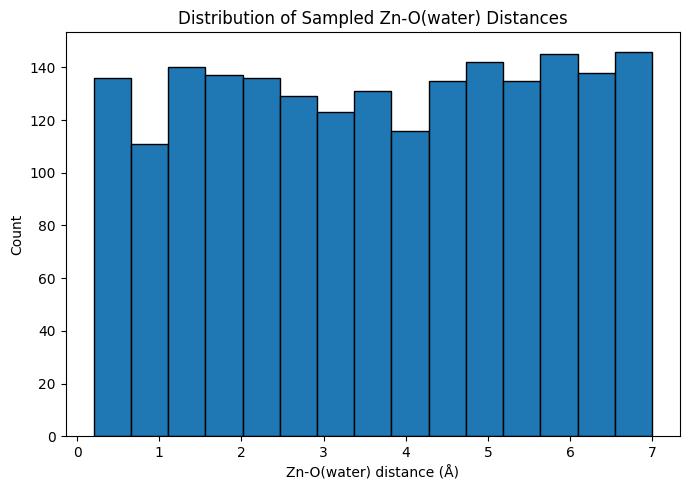

In [440]:
plt.figure(figsize=(7, 5))
plt.hist(df_clean["zn_o_water_distance_A"], bins=15, edgecolor="black")
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Count")
plt.title("Distribution of Sampled Zn-O(water) Distances")
plt.tight_layout()
plt.savefig(plot_dir / "distance_distribution.png", dpi=300)
plt.show()

## Bivariate Analysis

We examine relationships between pairs of variables, such as:

- Zn–O distance vs total energy
- Zn–O distance vs HOMO–LUMO gap

This allows us to identify whether solvent proximity systematically influences electronic structure.

### Total Energy Distribution

2000
1800


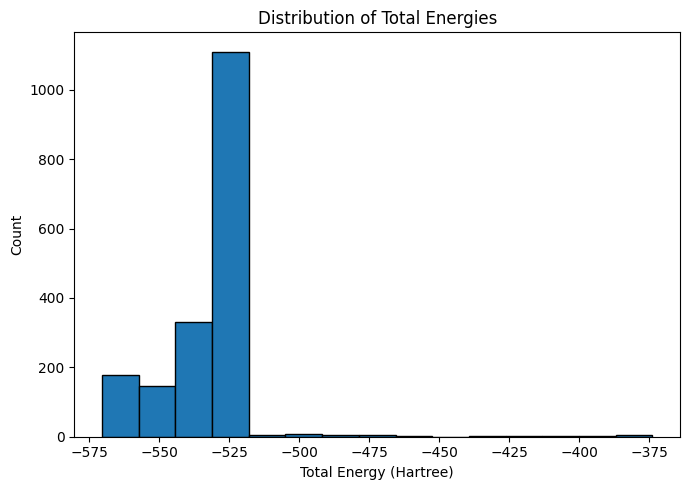

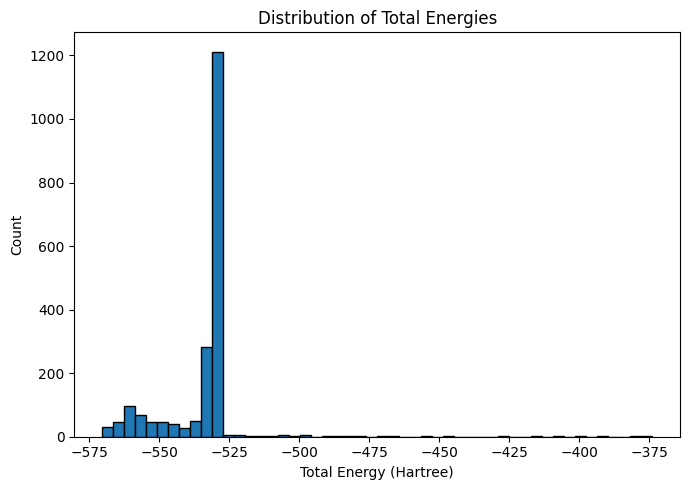

In [442]:
# =========================
# 2. TOTAL ENERGY DISTRIBUTION
# =========================

min_energy_start = 0
max_energy_end = -200

print(len(df_clean["total_energy_hartree"]))
print(len(df_clean["total_energy_hartree"][min_energy_start:max_energy_end]))


plt.figure(figsize=(7, 5))
#plt.hist(df_clean["total_energy_hartree"], bins=15, edgecolor="black")
plt.hist(df_clean["total_energy_hartree"][min_energy_start:max_energy_end], bins=15, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df_clean["total_energy_hartree"], bins=50, edgecolor="black")
#plt.hist(df_clean["total_energy_hartree"][min_energy_start:max_energy_end], bins=15, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution.png", dpi=300)
plt.show()

Original length: 2000
After index cut: 1800


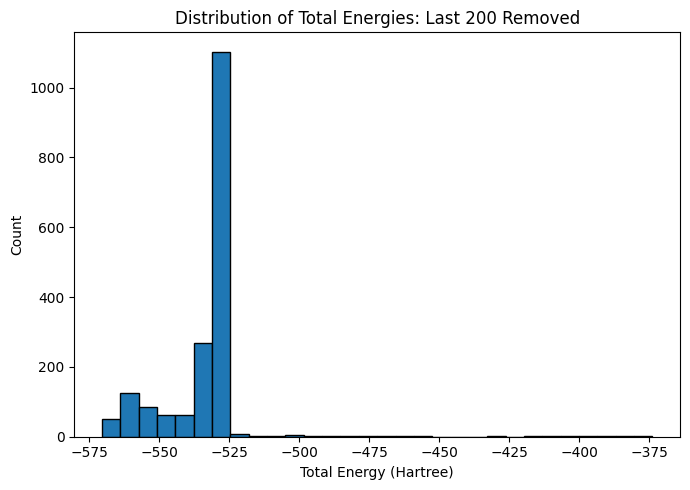

After value cut: 755


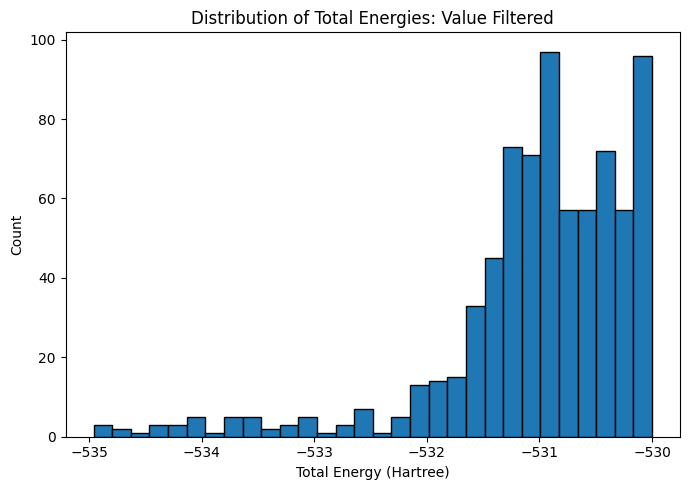

5th percentile: -561.4090526111729
95th percentile: -529.8171604033531
After percentile cut: 1800


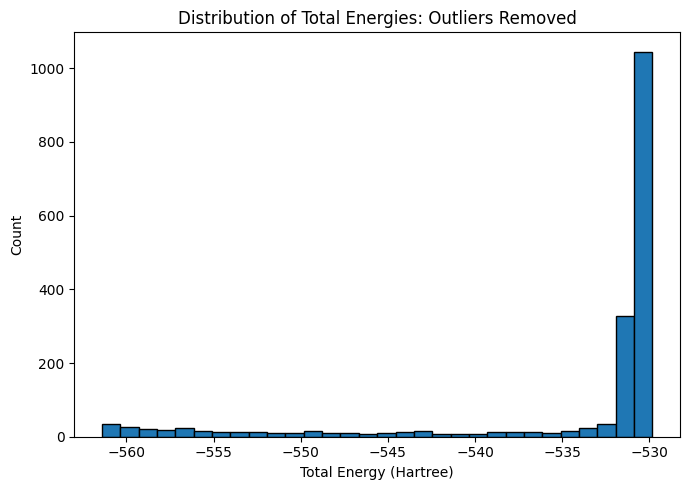

First few energies:
0   -530.383210
1   -559.941169
2   -531.284241
3   -529.818440
4   -529.883595
Name: total_energy_hartree, dtype: float64
Last few energies:
1995   -531.936135
1996   -529.816853
1997   -529.922938
1998   -530.031615
1999   -509.635914
Name: total_energy_hartree, dtype: float64


In [443]:
# =========================
# 2. TOTAL ENERGY DISTRIBUTION
# =========================

energy_col = "total_energy_hartree"

# -------------------------
# Option 1: Remove last 200 rows by index
# -------------------------
subset_index_cut = df_clean[energy_col].iloc[:-200]

print("Original length:", len(df_clean[energy_col]))
print("After index cut:", len(subset_index_cut))

plt.figure(figsize=(7, 5))
plt.hist(subset_index_cut, bins=30, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies: Last 200 Removed")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution_index_cut.png", dpi=300)
plt.show()


# -------------------------
# Option 2: Filter by energy value
# Change these numbers to match your data
# -------------------------
min_energy = -535
max_energy = -530

subset_value_cut = df_clean[
    (df_clean[energy_col] >= min_energy) &
    (df_clean[energy_col] <= max_energy)
][energy_col]

print("After value cut:", len(subset_value_cut))

plt.figure(figsize=(7, 5))
plt.hist(subset_value_cut, bins=30, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies: Value Filtered")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution_value_cut.png", dpi=300)
plt.show()


# -------------------------
# Option 3: Remove outliers using percentiles
# Keeps middle 90% of energies
# -------------------------
q_low = df_clean[energy_col].quantile(0.05)
q_high = df_clean[energy_col].quantile(0.95)

subset_percentile_cut = df_clean[
    (df_clean[energy_col] >= q_low) &
    (df_clean[energy_col] <= q_high)
][energy_col]

print("5th percentile:", q_low)
print("95th percentile:", q_high)
print("After percentile cut:", len(subset_percentile_cut))

plt.figure(figsize=(7, 5))
plt.hist(subset_percentile_cut, bins=30, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies: Outliers Removed")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution_percentile_cut.png", dpi=300)
plt.show()


# -------------------------
# Debug: see first and last values
# -------------------------
print("First few energies:")
print(df_clean[energy_col].head())

print("Last few energies:")
print(df_clean[energy_col].tail())

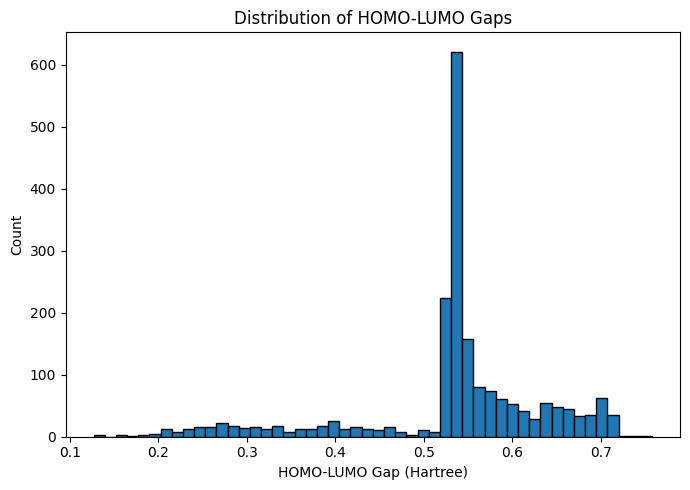

In [444]:

# =========================
# 3. HOMO-LUMO GAP DISTRIBUTION
# =========================

plt.figure(figsize=(7, 5))
plt.hist(df_clean["gap_hartree"], bins=50, edgecolor="black")
plt.xlabel("HOMO-LUMO Gap (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of HOMO-LUMO Gaps")
plt.tight_layout()
plt.savefig(plot_dir / "gap_distribution.png", dpi=300)
plt.show()


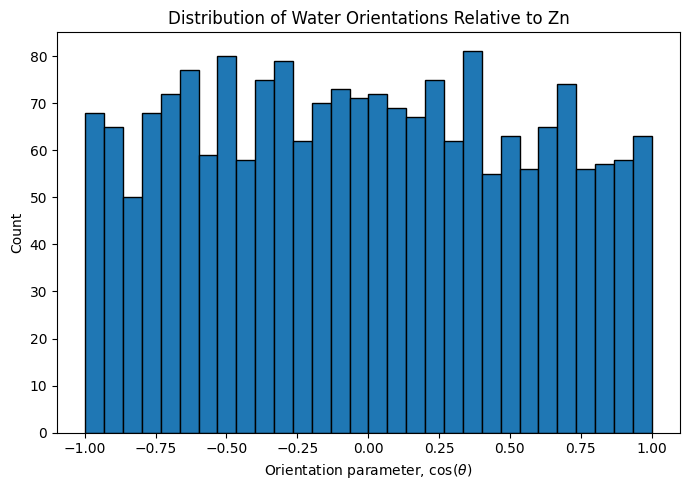

In [445]:
plt.figure(figsize=(7, 5))
plt.hist(df["cos_theta_orientation"].dropna(), bins=30, edgecolor="black")
plt.xlabel(r"Orientation parameter, $\cos(\theta)$")
plt.ylabel("Count")
plt.title("Distribution of Water Orientations Relative to Zn")
plt.tight_layout()
plt.show()

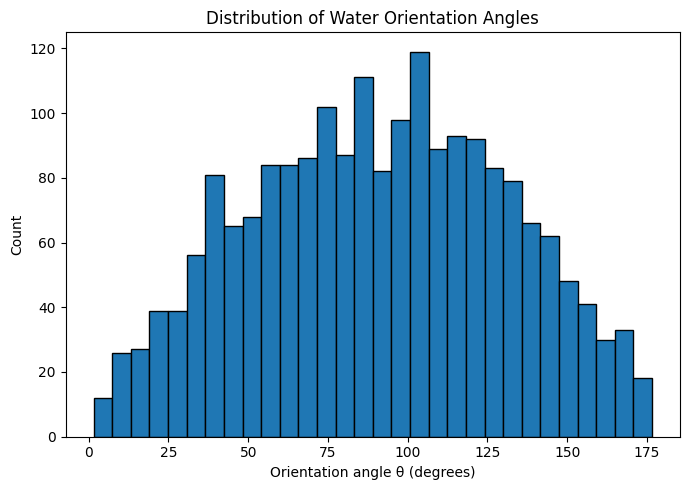

In [379]:
plt.figure(figsize=(7, 5))
plt.hist(df["theta_orientation_deg"].dropna(), bins=30, edgecolor="black")
plt.xlabel("Orientation angle θ (degrees)")
plt.ylabel("Count")
plt.title("Distribution of Water Orientation Angles")
plt.tight_layout()
plt.show()

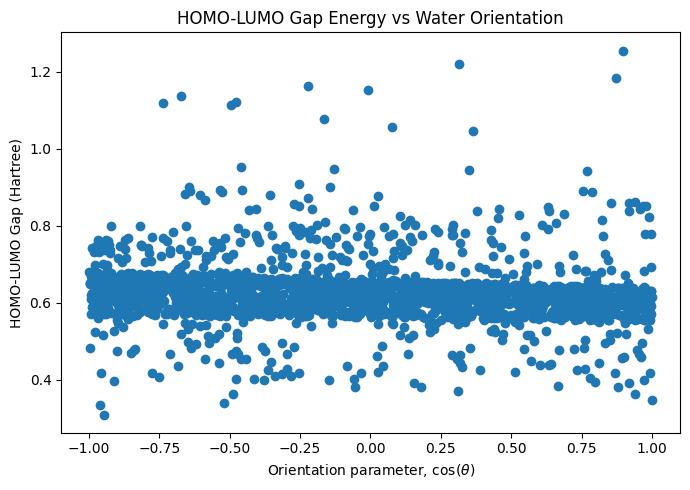

In [414]:
plt.figure(figsize=(7, 5))
plt.scatter(df["cos_theta_orientation"], df["gap_hartree"])
plt.xlabel(r"Orientation parameter, $\cos(\theta)$")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("HOMO-LUMO Gap Energy vs Water Orientation")
plt.tight_layout()
plt.show()


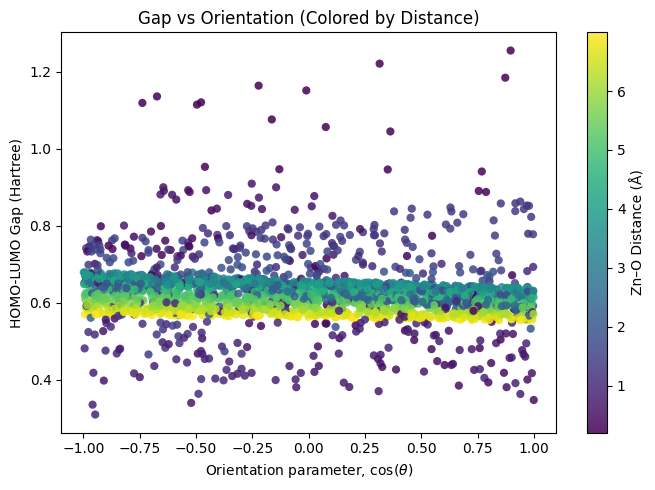

In [413]:

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df["cos_theta_orientation"],
    df["gap_hartree"],
    c=df["zn_o_water_distance_A"],
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Zn–O Distance (Å)")

plt.xlabel(r"Orientation parameter, $\cos(\theta)$")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gap vs Orientation (Colored by Distance)")
plt.tight_layout()
plt.show()

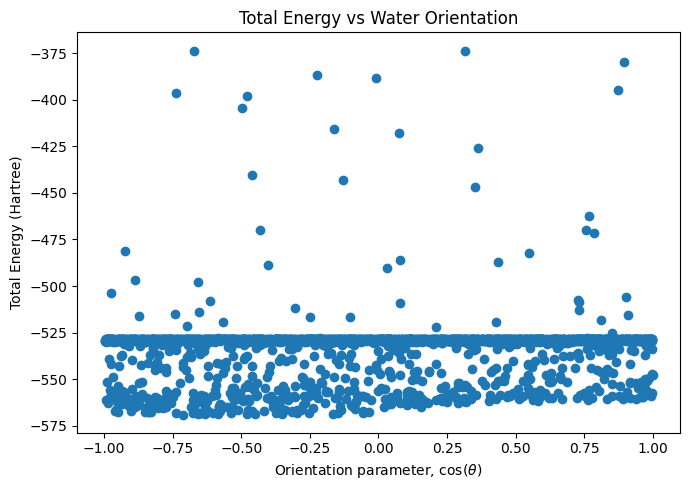

In [381]:
plt.figure(figsize=(7, 5))
plt.scatter(df["cos_theta_orientation"], df["total_energy_hartree"])
plt.xlabel(r"Orientation parameter, $\cos(\theta)$")
plt.ylabel("Total Energy (Hartree)")
plt.title("Total Energy vs Water Orientation")
plt.tight_layout()
plt.show()

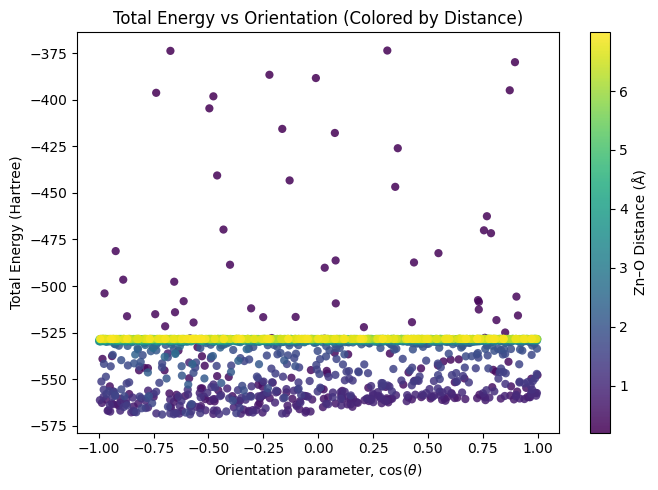

In [415]:
import numpy as np
import matplotlib.pyplot as plt

# Clean data
mask = (
    np.isfinite(df["cos_theta_orientation"]) &
    np.isfinite(df["total_energy_hartree"]) &
    np.isfinite(df["zn_o_water_distance_A"])
)

x = df["cos_theta_orientation"].values[mask]
y = df["total_energy_hartree"].values[mask]
c = df["zn_o_water_distance_A"].values[mask]

# Sort for better visual layering
sort_idx = np.argsort(c)
x = x[sort_idx]
y = y[sort_idx]
c = c[sort_idx]

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    x, y,
    c=c,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Zn–O Distance (Å)")

plt.xlabel(r"Orientation parameter, $\cos(\theta)$")
plt.ylabel("Total Energy (Hartree)")
plt.title("Total Energy vs Orientation (Colored by Distance)")
plt.tight_layout()
plt.show()

In [417]:
from scipy.optimize import curve_fit

def exp_model(x, a, b, c):
    return a * np.exp(-b * x) + c

x = df["zn_o_water_distance_A"]
y = df["gap_hartree"]

# clean NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]
params, covariance = curve_fit(exp_model, x, y)

y_pred = exp_model(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res/ss_tot

x_line = np.linspace(min(x), max(x), 100)
y_line = exp_model(x_line, *params)

plt.figure(figsize=(7, 5))
plt.scatter(
    df["zn_o_water_distance_A"],
    df["gap_hartree"],
    c=df["cos_theta_orientation"],label="Sampled configurations"
)

plt.plot(x_line, y_line,'r-',label=f"exponential fit $R^2$ = {r_squared:.3f}",linewidth=3)

plt.colorbar(label=r"Water orientation parameter, $\cos(\theta)$")
plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gap Energy (Ha) vs Distance (Å)")
plt.tight_layout()
plt.legend()
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

Fit parameters:
A = 73.6565
B = 0.0002
D = -0.0394
r0 = 2.2809 Å
sigma = -0.2033 Å
C = -72.9798 Ha
R² = 0.0940


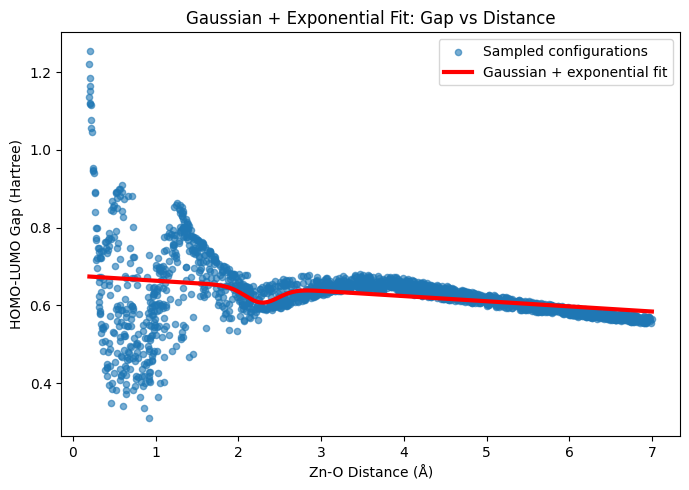

In [383]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# x = Zn-O distance
# y = HOMO-LUMO gap
x = df["zn_o_water_distance_A"].values
y = df["gap_hartree"].values

def gaussian_plus_exponential(r, A, B, D, r0, sigma, C):
    exponential_part = A * np.exp(-B * r)
    gaussian_bump = D * np.exp(-((r - r0)**2) / (2 * sigma**2))
    return exponential_part + gaussian_bump + C

# Initial guesses based on your plot
p0 = [
    -1.0,   # A: negative helps capture low gap at short distances
    1.0,    # B: exponential decay rate
    0.2,   # D: height of bump
    2.0,    # r0: bump centered near 2.1 Å
    0.45,   # sigma: bump width
    0.535   # C: far-away baseline gap
]

params, covariance = curve_fit(
    gaussian_plus_exponential,
    x,
    y,
    p0=p0,
    maxfev=10000
)

A, B, D, r0, sigma, C = params

# Smooth curve for plotting
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gaussian_plus_exponential(x_fit, *params)

# R^2 calculation
y_pred = gaussian_plus_exponential(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

print("Fit parameters:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"D = {D:.4f}")
print(f"r0 = {r0:.4f} Å")
print(f"sigma = {sigma:.4f} Å")
print(f"C = {C:.4f} Ha")
print(f"R² = {r_squared:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=20, alpha=0.6, label="Sampled configurations")
plt.plot(x_fit, y_fit, linewidth=3, label="Gaussian + exponential fit", color="red")

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gaussian + Exponential Fit: Gap vs Distance")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/3_/1dz80n8d1111xkcqpmfl5lr00000gn/T/ipykernel_27149/2879203986.py:26: RuntimeWarning: overflow encountered in square
  morse_part = De * (1 - np.exp(-a * (r - re)))**2


Fit parameters:
De = 767.1698
a  = 0.5728
re = -4.2384 Å
A  = 131.5316
B  = 0.5634
C  = -766.7125 Ha
R² = 0.6351


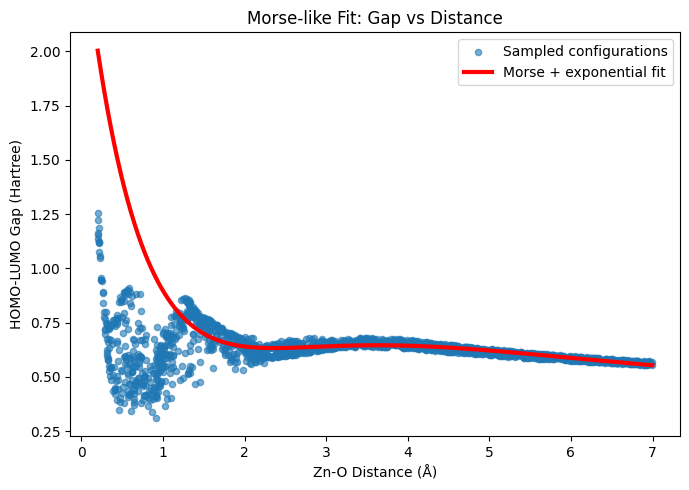

In [384]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# x = Zn-O distance
# y = HOMO-LUMO gap
x = df["zn_o_water_distance_A"].values
y = df["gap_hartree"].values

# Clean NaNs/infs
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

def morse_plus_exponential(r, De, a, re, A, B, C):
    """
    Morse-like well + exponential term + baseline.

    De = well depth / amplitude
    a  = well width/steepness
    re = equilibrium-like distance
    A  = exponential amplitude
    B  = exponential decay rate
    C  = baseline gap at long distance
    """
    morse_part = De * (1 - np.exp(-a * (r - re)))**2
    exponential_part = A * np.exp(-B * r)
    return morse_part + exponential_part + C

# Optional: remove very short unphysical distances
fit_mask = x > 1.2
x_fit_data = x[fit_mask]
y_fit_data = y[fit_mask]

# Initial guesses based on your plot
p0 = [
    0.08,   # De: Morse amplitude
    1.0,    # a: width/steepness
    2.2,    # re: minimum near Zn-O interaction region
    0.15,   # A: exponential amplitude
    0.8,    # B: exponential decay rate
    0.55    # C: long-distance baseline gap
]

params, covariance = curve_fit(
    morse_plus_exponential,
    x_fit_data,
    y_fit_data,
    p0=p0,
    maxfev=50000
)

De, a, re, A, B, C = params

# Smooth curve for plotting
x_curve = np.linspace(x.min(), x.max(), 500)
y_curve = morse_plus_exponential(x_curve, *params)

# R^2 calculation on fitted region
y_pred = morse_plus_exponential(x_fit_data, *params)
ss_res = np.sum((y_fit_data - y_pred)**2)
ss_tot = np.sum((y_fit_data - np.mean(y_fit_data))**2)
r_squared = 1 - (ss_res / ss_tot)

print("Fit parameters:")
print(f"De = {De:.4f}")
print(f"a  = {a:.4f}")
print(f"re = {re:.4f} Å")
print(f"A  = {A:.4f}")
print(f"B  = {B:.4f}")
print(f"C  = {C:.4f} Ha")
print(f"R² = {r_squared:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=20, alpha=0.6, label="Sampled configurations")
plt.plot(
    x_curve,
    y_curve,
    linewidth=3,
    label="Morse + exponential fit",
    color="red"
)

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Morse-like Fit: Gap vs Distance")
plt.legend()
plt.tight_layout()
plt.show()

Fit parameters:
A  = 2.4269
B  = 0.7919
C  = 0.5624 Ha
G1 = 1.5989
r1 = 0.3000 Å  <-- first dip
s1 = 0.6097 Å
G2 = 0.3907
r2 = 1.8574 Å  <-- second dip
s2 = 0.8126 Å
R² = 0.4591


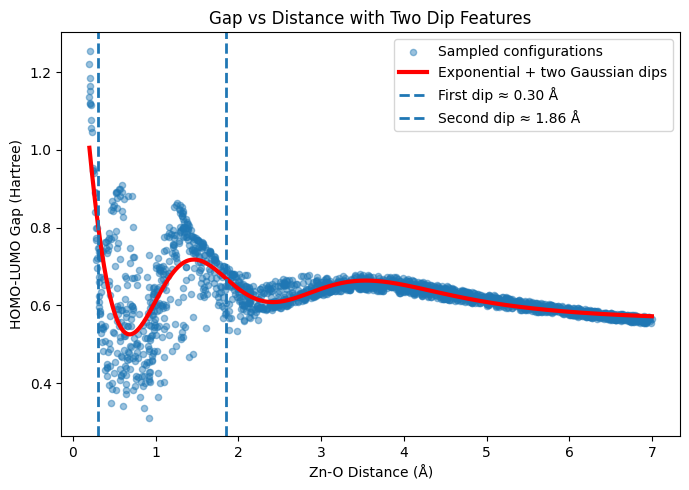

In [386]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = df["zn_o_water_distance_A"].values
y = df["gap_hartree"].values

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

def exp_plus_two_gaussian_dips(r, A, B, C, G1, r1, s1, G2, r2, s2):
    baseline = C + A * np.exp(-B * r)

    dip1 = -G1 * np.exp(-((r - r1)**2) / (2 * s1**2))
    dip2 = -G2 * np.exp(-((r - r2)**2) / (2 * s2**2))

    return baseline + dip1 + dip2

p0 = [
    0.20,   # A: short-range exponential amplitude
    0.8,    # B: exponential decay rate
    0.60,   # C: baseline

    0.20,   # G1: first dip depth
    0.80,   # r1: first dip position
    0.20,   # s1: first dip width

    0.07,   # G2: second dip depth
    2.20,   # r2: second dip position
    0.35    # s2: second dip width
]

bounds = (
    [ -5, 0, 0.2,   0, 0.3, 0.05,   0, 1.6, 0.05],
    [  5, 5, 1.5,   2, 1.2, 0.7,    1, 2.8, 1.0]
)

params, covariance = curve_fit(
    exp_plus_two_gaussian_dips,
    x,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=50000
)

A, B, C, G1, r1, s1, G2, r2, s2 = params

x_curve = np.linspace(x.min(), x.max(), 800)
y_curve = exp_plus_two_gaussian_dips(x_curve, *params)

y_pred = exp_plus_two_gaussian_dips(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res / ss_tot

print("Fit parameters:")
print(f"A  = {A:.4f}")
print(f"B  = {B:.4f}")
print(f"C  = {C:.4f} Ha")
print(f"G1 = {G1:.4f}")
print(f"r1 = {r1:.4f} Å  <-- first dip")
print(f"s1 = {s1:.4f} Å")
print(f"G2 = {G2:.4f}")
print(f"r2 = {r2:.4f} Å  <-- second dip")
print(f"s2 = {s2:.4f} Å")
print(f"R² = {r_squared:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=20, alpha=0.45, label="Sampled configurations")
plt.plot(x_curve, y_curve, linewidth=3, color="red", label="Exponential + two Gaussian dips")

plt.axvline(r1, linestyle="--", linewidth=2, label=f"First dip ≈ {r1:.2f} Å")
plt.axvline(r2, linestyle="--", linewidth=2, label=f"Second dip ≈ {r2:.2f} Å")

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gap vs Distance with Two Dip Features")
plt.legend()
plt.tight_layout()
plt.show()

['sample', 'zn_o_water_distance_A', 'total_energy_hartree', 'homo_hartree', 'lumo_hartree', 'gap_hartree', 'converged', 'cos_theta_orientation', 'theta_orientation_deg', 'xyz_file']
Using rotational column: cos_theta_orientation


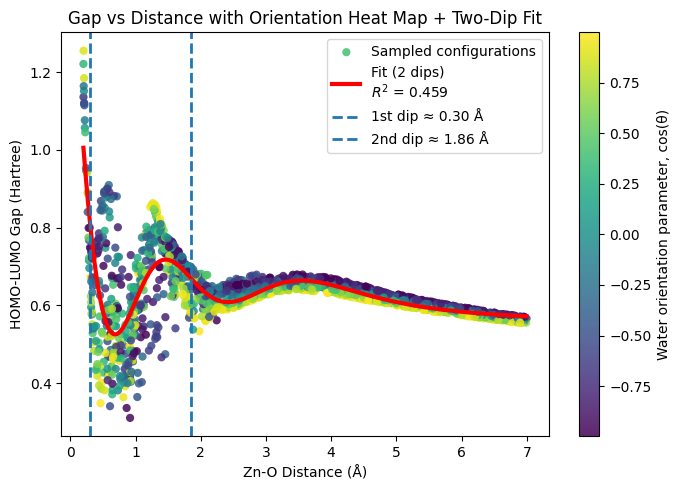


Fit parameters:
A  = 2.4269
B  = 0.7919
C  = 0.5624 Ha
G1 = 1.5989
r1 = 0.3000 Å  <-- first dip
s1 = 0.6097 Å
G2 = 0.3907
r2 = 1.8574 Å  <-- second dip
s2 = 0.8126 Å
R² = 0.4591


In [387]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# DATA
# =========================
x = df["zn_o_water_distance_A"].values
y = df["gap_hartree"].values

# Find rotational column automatically
print(df.columns.tolist())

possible_rot_cols = [
    "cos_theta_orientation",
    "cos_theta",
    "water_orientation",
    "orientation",
    "rotational_parameter",
    "rotation_parameter",
    "cos(theta)"
]

rot_col = None
for col in possible_rot_cols:
    if col in df.columns:
        rot_col = col
        break

if rot_col is None:
    raise KeyError("Could not find rotational/orientation column.")

rot = df[rot_col].values
print("Using rotational column:", rot_col)

# Clean NaNs
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(rot)
x = x[mask]
y = y[mask]
rot = rot[mask]

# =========================
# MODEL: exponential + TWO dips
# =========================
def exp_plus_two_gaussian_dips(r, A, B, C, G1, r1, s1, G2, r2, s2):
    baseline = C + A * np.exp(-B * r)
    dip1 = -G1 * np.exp(-((r - r1)**2) / (2 * s1**2))
    dip2 = -G2 * np.exp(-((r - r2)**2) / (2 * s2**2))
    return baseline + dip1 + dip2

# Initial guesses
p0 = [
    0.20,   # A
    0.8,    # B
    0.60,   # C

    0.20,   # G1
    0.80,   # r1
    0.20,   # s1

    0.07,   # G2
    2.20,   # r2
    0.35    # s2
]

bounds = (
    [ -5, 0, 0.2,   0, 0.3, 0.05,   0, 1.6, 0.05],
    [  5, 5, 1.5,   2, 1.2, 0.7,    1, 2.8, 1.0]
)

params, covariance = curve_fit(
    exp_plus_two_gaussian_dips,
    x,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=50000
)

# =========================
# FIT CURVE
# =========================
x_curve = np.linspace(x.min(), x.max(), 800)
y_curve = exp_plus_two_gaussian_dips(x_curve, *params)

# R^2
y_pred = exp_plus_two_gaussian_dips(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res / ss_tot

A, B, C, G1, r1, s1, G2, r2, s2 = params

# =========================
# PLOT WITH HEAT MAP
# =========================
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    x, y,
    c=rot,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none",
    label="Sampled configurations"
)

plt.plot(
    x_curve, y_curve,
    color="red",
    linewidth=3,
    label=f"Fit (2 dips)\n$R^2$ = {r_squared:.3f}"
)

# Mark dip positions
plt.axvline(r1, linestyle="--", linewidth=2, label=f"1st dip ≈ {r1:.2f} Å")
plt.axvline(r2, linestyle="--", linewidth=2, label=f"2nd dip ≈ {r2:.2f} Å")

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Water orientation parameter, cos(θ)")

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gap vs Distance with Orientation Heat Map + Two-Dip Fit")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# PRINT PARAMETERS
# =========================
print("\nFit parameters:")
print(f"A  = {A:.4f}")
print(f"B  = {B:.4f}")
print(f"C  = {C:.4f} Ha")
print(f"G1 = {G1:.4f}")
print(f"r1 = {r1:.4f} Å  <-- first dip")
print(f"s1 = {s1:.4f} Å")
print(f"G2 = {G2:.4f}")
print(f"r2 = {r2:.4f} Å  <-- second dip")
print(f"s2 = {s2:.4f} Å")
print(f"R² = {r_squared:.4f}")

In [388]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = df["zn_o_water_distance_A"].values
y = df["gap_hartree"].values
# Look for the correct rotational/orientation column
print(df.columns.tolist())

# Common possible names:
possible_rot_cols = [
    "cos_theta_orientation",
    "cos_theta",
    "water_orientation",
    "orientation",
    "rotational_parameter",
    "rotation_parameter",
    "cos(theta)"
]

rot_col = None
for col in possible_rot_cols:
    if col in df.columns:
        rot_col = col
        break

if rot_col is None:
    raise KeyError("Could not find rotational/orientation column. Check df.columns above.")

rot = df[rot_col].values
print("Using rotational column:", rot_col)

def gaussian_plus_exponential(r, A, B, D, r0, sigma, C):
    return A*np.exp(-B*r) + D*np.exp(-((r-r0)**2)/(2*sigma**2)) + C

p0 = [-1.0, 1.0, 0.18, 2.1, 0.45, 0.535]

params, covariance = curve_fit(
    gaussian_plus_exponential,
    x,
    y,
    p0=p0,
    maxfev=10000
)

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gaussian_plus_exponential(x_fit, *params)

y_pred = gaussian_plus_exponential(x, *params)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res/ss_tot

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    x, y,
    c=rot,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none",
    label="Sampled configurations"
)

plt.plot(
    x_fit, y_fit,
    color="red",
    linewidth=3,
    label=f"Gaussian + exponential fit\n$R^2$ = {r_squared:.3f}"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Water orientation parameter, cos(θ)")

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Gap Energy vs Distance with Orientation Heat Map and Curve Fit")
plt.legend()
plt.tight_layout()
plt.show()

print("Fit parameters:")
print(f"A = {params[0]:.4f}")
print(f"B = {params[1]:.4f}")
print(f"D = {params[2]:.4f}")
print(f"r0 = {params[3]:.4f} Å")
print(f"sigma = {params[4]:.4f} Å")
print(f"C = {params[5]:.4f} Ha")
print(f"R² = {r_squared:.4f}")

['sample', 'zn_o_water_distance_A', 'total_energy_hartree', 'homo_hartree', 'lumo_hartree', 'gap_hartree', 'converged', 'cos_theta_orientation', 'theta_orientation_deg', 'xyz_file']
Using rotational column: cos_theta_orientation


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

## HOMO-LUMO Gap Distribution

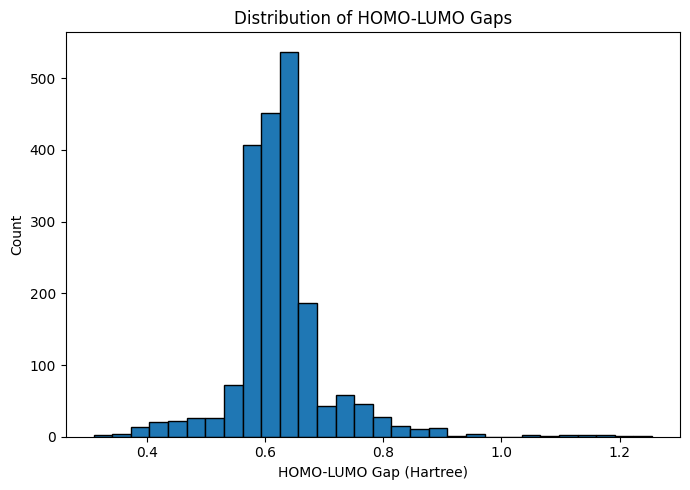

In [389]:

# =========================
# 3. HOMO-LUMO GAP DISTRIBUTION
# =========================

plt.figure(figsize=(7, 5))
plt.hist(df_clean["gap_hartree"], bins=30, edgecolor="black")
plt.xlabel("HOMO-LUMO Gap (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of HOMO-LUMO Gaps")
plt.tight_layout()
plt.savefig(plot_dir / "gap_distribution.png", dpi=300)
plt.show()


## Distance vs Energy

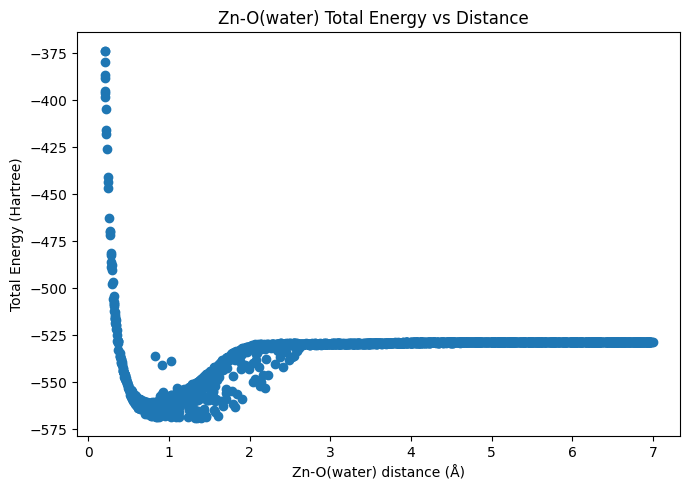

In [420]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["zn_o_water_distance_A"],
    df["total_energy_hartree"]
)
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Total Energy (Hartree)")
plt.title("Zn-O(water) Total Energy vs Distance  ")
plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_energy.png", dpi=300)
plt.show()

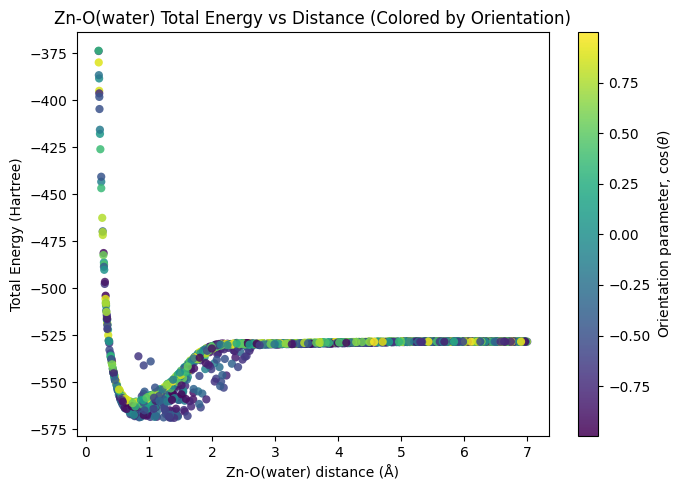

In [422]:
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df["zn_o_water_distance_A"],
    df["total_energy_hartree"],
    c=df["cos_theta_orientation"],   # 🔥 color by orientation
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label(r"Orientation parameter, $\cos(\theta)$")

plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Total Energy (Hartree)")
plt.title("Zn-O(water) Total Energy vs Distance (Colored by Orientation)")

plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_energy.png", dpi=300)
plt.show()

In [418]:
import numpy as np
import matplotlib.pyplot as plt

# Clean data
mask = (
    np.isfinite(df_clean["zn_o_water_distance_A"]) &
    np.isfinite(df_clean["total_energy_hartree"]) &
    np.isfinite(df_clean["cos_theta_orientation"])
)

x = df_clean["zn_o_water_distance_A"].values[mask]
y = df_clean["total_energy_hartree"].values[mask]
c = df_clean["cos_theta_orientation"].values[mask]

# Sort by orientation for better visual layering
sort_idx = np.argsort(c)
x = x[sort_idx]
y = y[sort_idx]
c = c[sort_idx]

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    x, y,
    c=c,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolor="none"
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(r"Orientation parameter, $\cos(\theta)$")

plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Total Energy (Hartree)")
plt.title("Total Energy vs Distance (Colored by Orientation)")

plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_energy_orientation_heatmap.png", dpi=300)
plt.show()

KeyError: 'cos_theta_orientation'

In [419]:
print(df_clean.columns.tolist())

['zn_o_water_distance_A', 'total_energy_hartree', 'gap_hartree']


## Distance vs HOMO-LUMO Gap

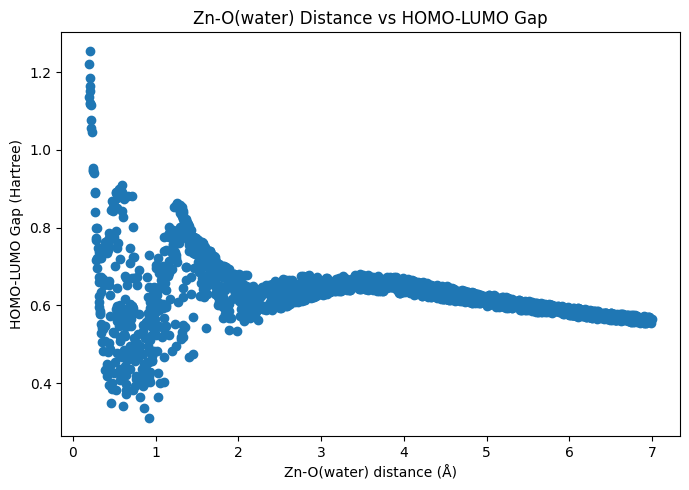

In [406]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["zn_o_water_distance_A"],
    df_clean["gap_hartree"]
)
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Zn-O(water) Distance vs HOMO-LUMO Gap")
plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_gap.png", dpi=300)
plt.show()

## Energy vs Gap

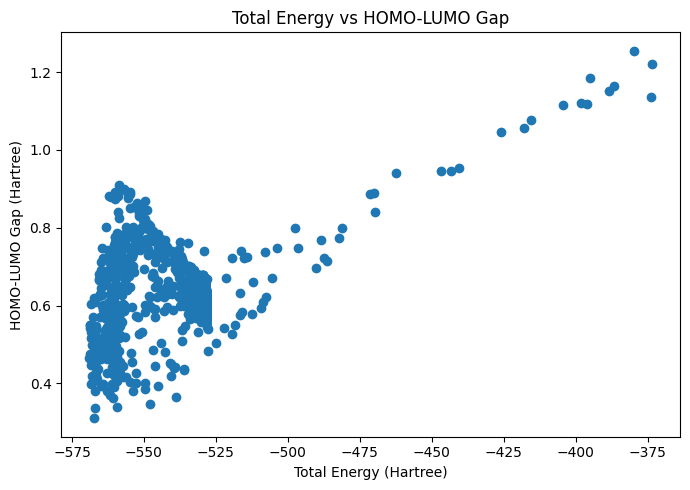

In [407]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["total_energy_hartree"],
    df_clean["gap_hartree"]
)
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Total Energy vs HOMO-LUMO Gap")
plt.tight_layout()
plt.savefig(plot_dir / "energy_vs_gap.png", dpi=300)
plt.show()


## Statistical Inference via Bootstrapping

To estimate uncertainty in our results, we apply bootstrap resampling.

Bootstrapping allows us to estimate confidence intervals for quantities such as:
- mean energy
- mean HOMO–LUMO gap
- mean Zn–O distance

This provides a non-parametric estimate of uncertainty without assuming a specific distribution.

### Bootstrap Confidence intervals

In [408]:
# =========================
# 7. BOOTSTRAP CONFIDENCE INTERVALS
# =========================

def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.array(data)
    boot_means = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    mean = np.mean(data)

    return mean, lower, upper, boot_means


energy_mean, energy_low, energy_high, energy_boot = bootstrap_ci(
    df_clean["total_energy_hartree"]
)

gap_mean, gap_low, gap_high, gap_boot = bootstrap_ci(
    df_clean["gap_hartree"]
)

distance_mean, distance_low, distance_high, distance_boot = bootstrap_ci(
    df_clean["zn_o_water_distance_A"]
)

print("\nBootstrap 95% Confidence Intervals")
print(f"Energy mean:   {energy_mean:.8f} Ha, CI [{energy_low:.8f}, {energy_high:.8f}]")
print(f"Gap mean:      {gap_mean:.8f} Ha, CI [{gap_low:.8f}, {gap_high:.8f}]")
print(f"Distance mean: {distance_mean:.4f} Å, CI [{distance_low:.4f}, {distance_high:.4f}]")



Bootstrap 95% Confidence Intervals
Energy mean:   -533.75902105 Ha, CI [-534.47859203, -533.00489679]
Gap mean:      0.62678191 Ha, CI [0.62308420, 0.63036087]
Distance mean: 3.5612 Å, CI [3.4715, 3.6524]


## Bootstrap histogram: Energy Mean

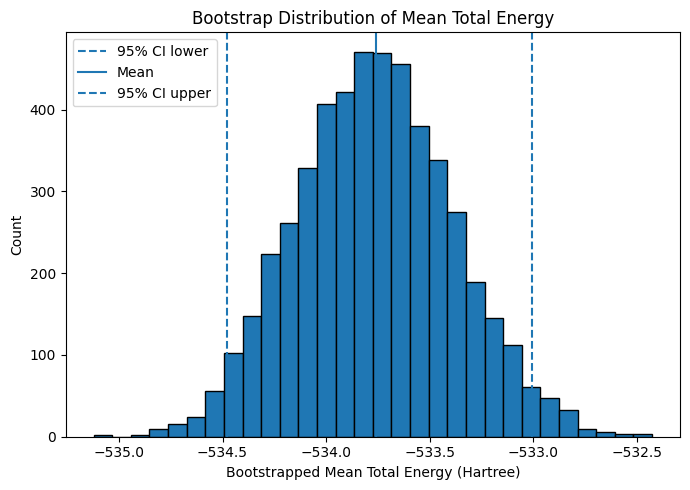

In [423]:
plt.figure(figsize=(7, 5))
plt.hist(energy_boot, bins=30, edgecolor="black")
plt.axvline(energy_low, linestyle="--", label="95% CI lower")
plt.axvline(energy_mean, linestyle="-", label="Mean")
plt.axvline(energy_high, linestyle="--", label="95% CI upper")
plt.xlabel("Bootstrapped Mean Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Mean Total Energy")
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "bootstrap_energy_mean.png", dpi=300)
plt.show()

## Bootstrap histogram: HOMO-LUMO Gap Mean

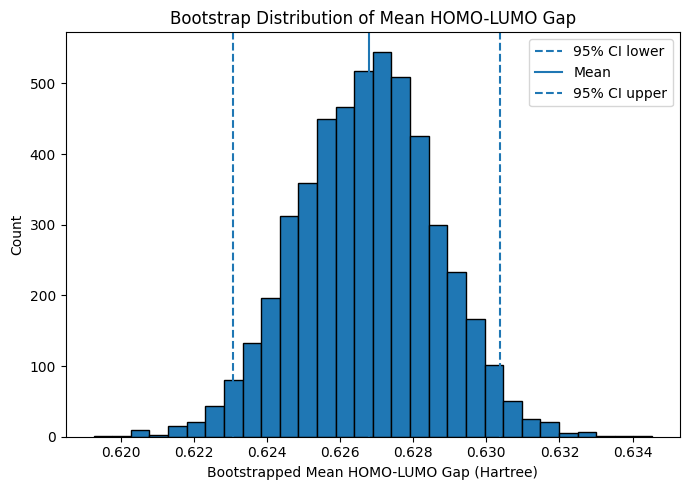


Plots saved in: water_sampling_plots


In [424]:
plt.figure(figsize=(7, 5))
plt.hist(gap_boot, bins=30, edgecolor="black")
plt.axvline(gap_low, linestyle="--", label="95% CI lower")
plt.axvline(gap_mean, linestyle="-", label="Mean")
plt.axvline(gap_high, linestyle="--", label="95% CI upper")
plt.xlabel("Bootstrapped Mean HOMO-LUMO Gap (Hartree)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Mean HOMO-LUMO Gap")
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "bootstrap_gap_mean.png", dpi=300)
plt.show()


print(f"\nPlots saved in: {plot_dir}")

## Interpretation

The results demonstrate that stochastic solvent placement introduces variability in both geometric and electronic properties of the active site.

Even small perturbations in solvent position lead to measurable fluctuations in energy and orbital structure, highlighting the importance of treating molecular systems as statistical ensembles rather than single configurations.

This aligns with principles of statistical mechanics, where observable properties arise from distributions over many microstates.

In [425]:
cols = ["zn_o_water_distance_A", "total_energy_hartree", "gap_hartree"]

df_clean = df[cols].dropna()

corr = df_clean.corr()

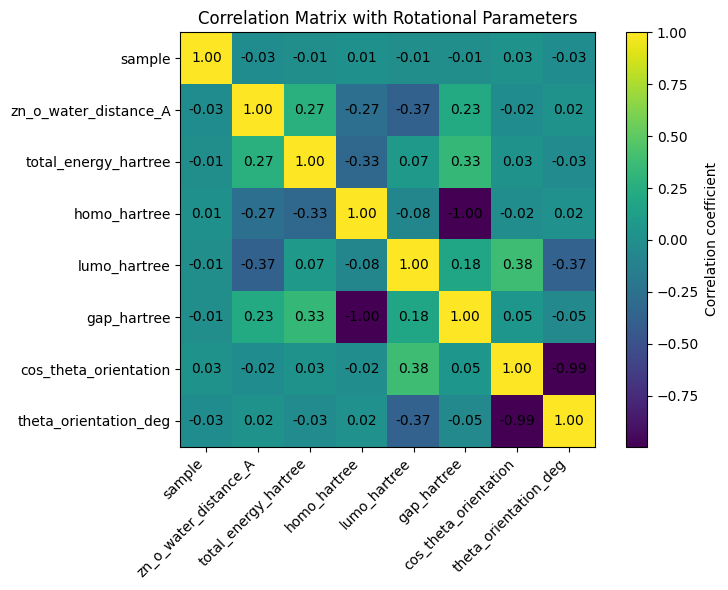

In [446]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix with Rotational Parameters")
plt.tight_layout()
plt.show()

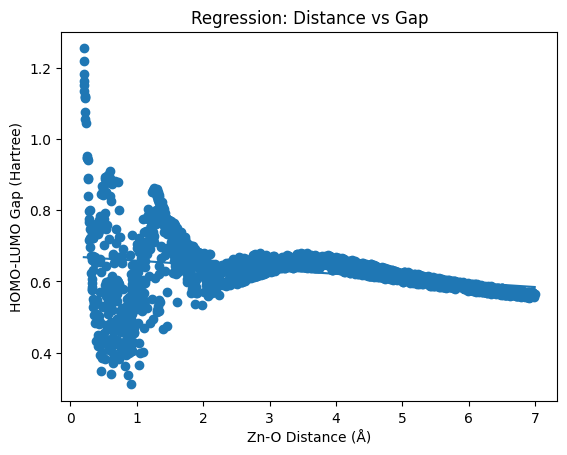

Slope: -0.012344360784952798
R^2: 0.08497207620492553


In [398]:
from scipy.stats import linregress
import numpy as np

x = df["zn_o_water_distance_A"]
y = df["gap_hartree"]

# remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

# plot
import matplotlib.pyplot as plt

plt.scatter(x, y)

x_line = np.linspace(min(x), max(x), 100)
y_line = intercept + slope * x_line

plt.plot(x_line, y_line)

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Regression: Distance vs Gap")

plt.show()

print("Slope:", slope)
print("R^2:", r_value**2)

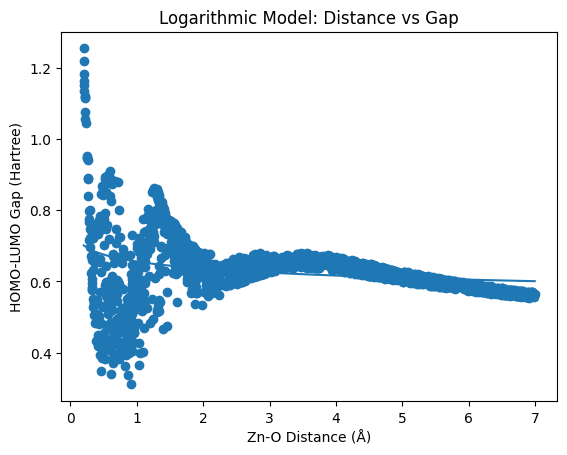

R^2: 0.07316653573842648


In [399]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

x = df["zn_o_water_distance_A"]
y = df["gap_hartree"]

# clean NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# take log of x
log_x = np.log(x)

# linear regression on log(x)
slope, intercept, r_value, p_value, std_err = linregress(log_x, y)

# plot
plt.scatter(x, y)

x_line = np.linspace(min(x), max(x), 100)
y_line = intercept + slope * np.log(x_line)

plt.plot(x_line, y_line)

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Logarithmic Model: Distance vs Gap")

plt.show()

print("R^2:", r_value**2)

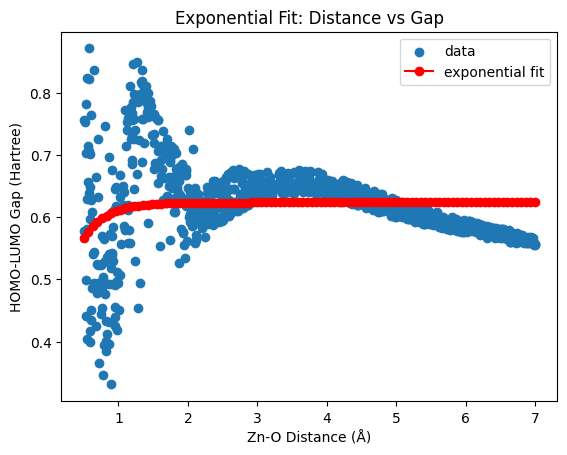

In [360]:
from scipy.optimize import curve_fit

def exp_model(x, a, b, c):
    return a * np.exp(-b * x) + c

params, _ = curve_fit(exp_model, x, y)

x_line = np.linspace(min(x), max(x), 100)
y_line = exp_model(x_line, *params)

plt.scatter(x, y,label="data")
plt.plot(x_line, y_line,'r-o',label="exponential fit")

plt.xlabel("Zn-O Distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Exponential Fit: Distance vs Gap")
plt.legend()
plt.show()

In [361]:
from scipy.stats import ttest_ind

# Split data into two groups
median_dist = df["zn_o_water_distance_A"].median()

close = df[df["zn_o_water_distance_A"] < median_dist]
far = df[df["zn_o_water_distance_A"] >= median_dist]

# Perform t-test
t_stat, p_value = ttest_ind(
    close["total_energy_hartree"].dropna(),
    far["total_energy_hartree"].dropna()
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -20.607705376952243
p-value: 6.757510795167198e-79
